In [1]:
from openpytea import Equipment, Plant, cash_flow_data, plot_cash_flow

In [2]:
reactor = Equipment(
    name="Reactor R-101",
    param=50,
    process_type="Fluids",
    category="Reactors",
    type="Glass-lined agitated",
    material="316 stainless steel",
)

hx = Equipment(
    name="HX-101",
    param=900,
    process_type="Fluids",
    category="Heat Exchangers",
    type="U-tube shell & tube",
    material="316 stainless steel",
)

comp = Equipment(
    name="Compressor C-101",
    param=1_000,
    process_type="Fluids",
    category="Compressors, fans, & blowers",
    type="Compressor, centrifugal",
)

config_a = {
    "plant_name": "Plant A",
    "process_type": "Fluids",
    "country": "United States",
    "region": "Gulf Coast",
    "currency": "USD",
    "equipment": [reactor, hx, comp],
    "interest_rate": 0.09,
    "project_lifetime": 20,
    "plant_utilization": 0.90,
    "tax_rate": 0.25,
    "operator_hourly_rate": {"rate": 35},
    "plant_products": {
        "methanol": {"production": 100_000, "price": 2.5},  # units/day, USD/unit
    },
    "variable_opex_inputs": {
        "electricity": {"consumption": 1.5e6, "price": 0.08},
        "cooling_water": {"consumption": 1.0e6, "price": 0.0007},
    },
}

plant_a = Plant(config_a)
print(plant_a)

ProcessPlant Configuration
----------------------------------------
Plant Name:                 Plant A
Process Type:               Fluids
Country / Region:           United States / Gulf Coast
Interest Rate:              0.09
Project Lifetime (years):   20
Plant Utilization:          0.9
Tax Rate:                   0.25
Working Capital:            None
Depreciation Settings:      None

Operator Labor Inputs
  Hourly Rate:              {
    "rate": 35
}
  Operators per Shift:      None
  Operators Hired:          None
  Working Weeks / Year:     49
  Working Shifts / Week:    5
  Operating Shifts / Day:   3

Products
{
    "methanol": {
        "production": 100000,
        "price": 2.5
    }
}

Variable OPEX Inputs:
{
    "electricity": {
        "consumption": 1500000.0,
        "price": 0.08
    },
    "cooling_water": {
        "consumption": 1000000.0,
        "price": 0.0007
    }
}

Additional CAPEX:
  Years:                    None
  Costs:                    None

Equipment L

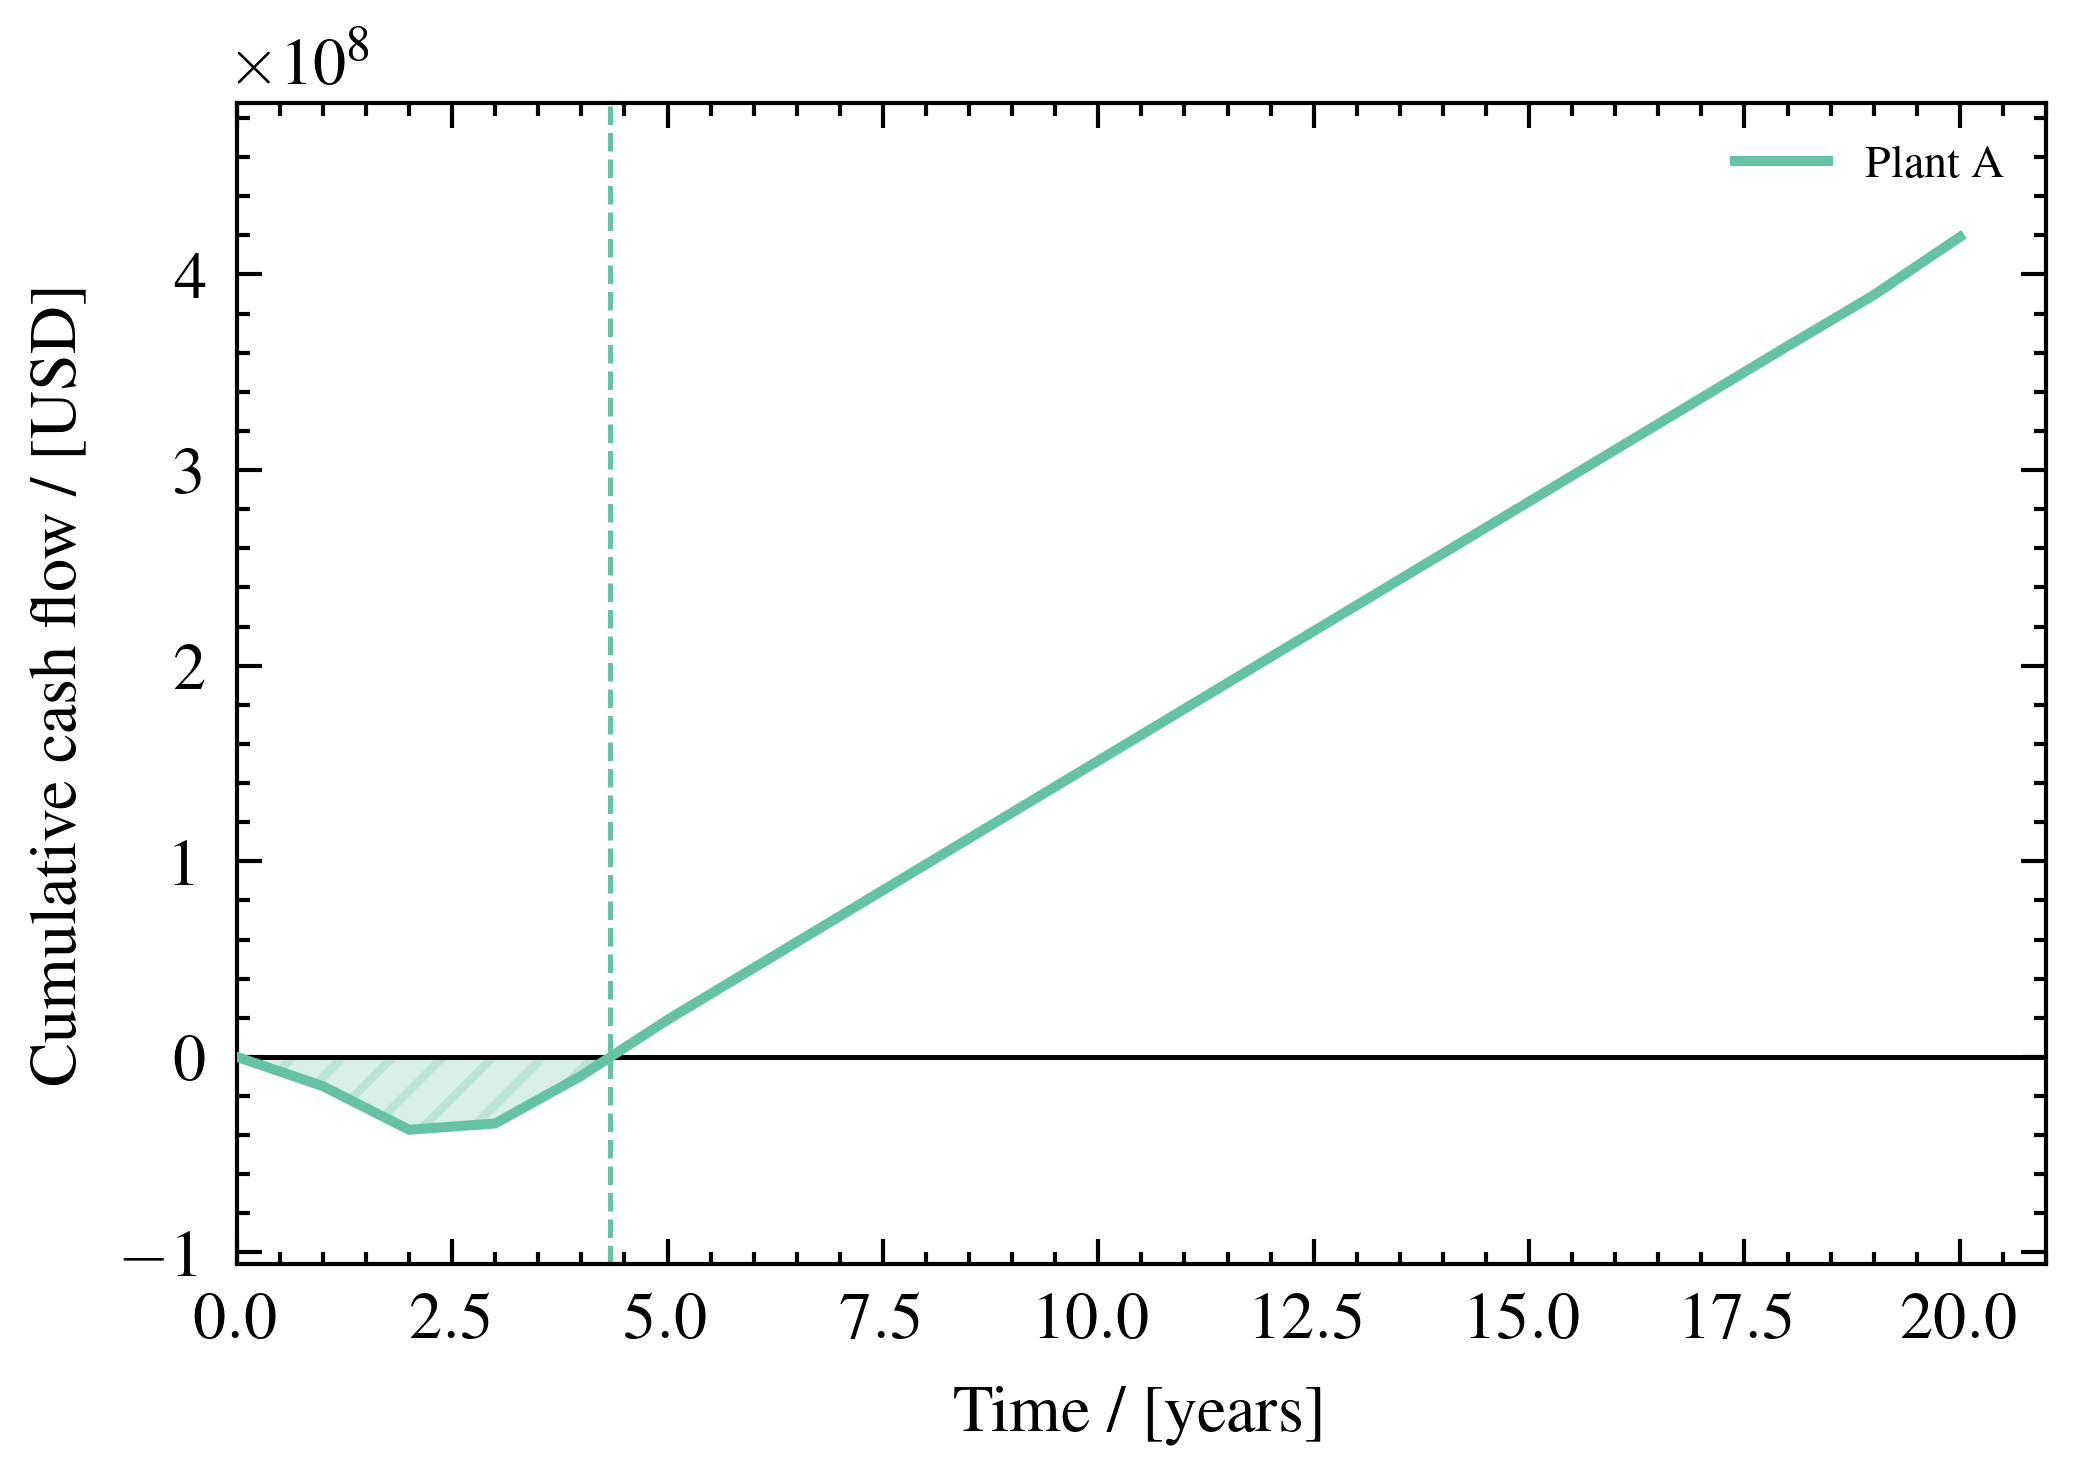

In [3]:
# Single-plant cash flow diagram
data_a = cash_flow_data(plant_a)
fig, ax = plot_cash_flow(data_a)

In [4]:
# Key metrics computed alongside the curve
curve_a = data_a["curves"][0]
print("Max investment:", curve_a["max_investment"], "at year", curve_a["max_investment_year"])
print("Pay-back time:", curve_a["payback_time"], "years")

Max investment: 37259912.09518291 at year 2.0
Pay-back time: 4.3379894841071005 years


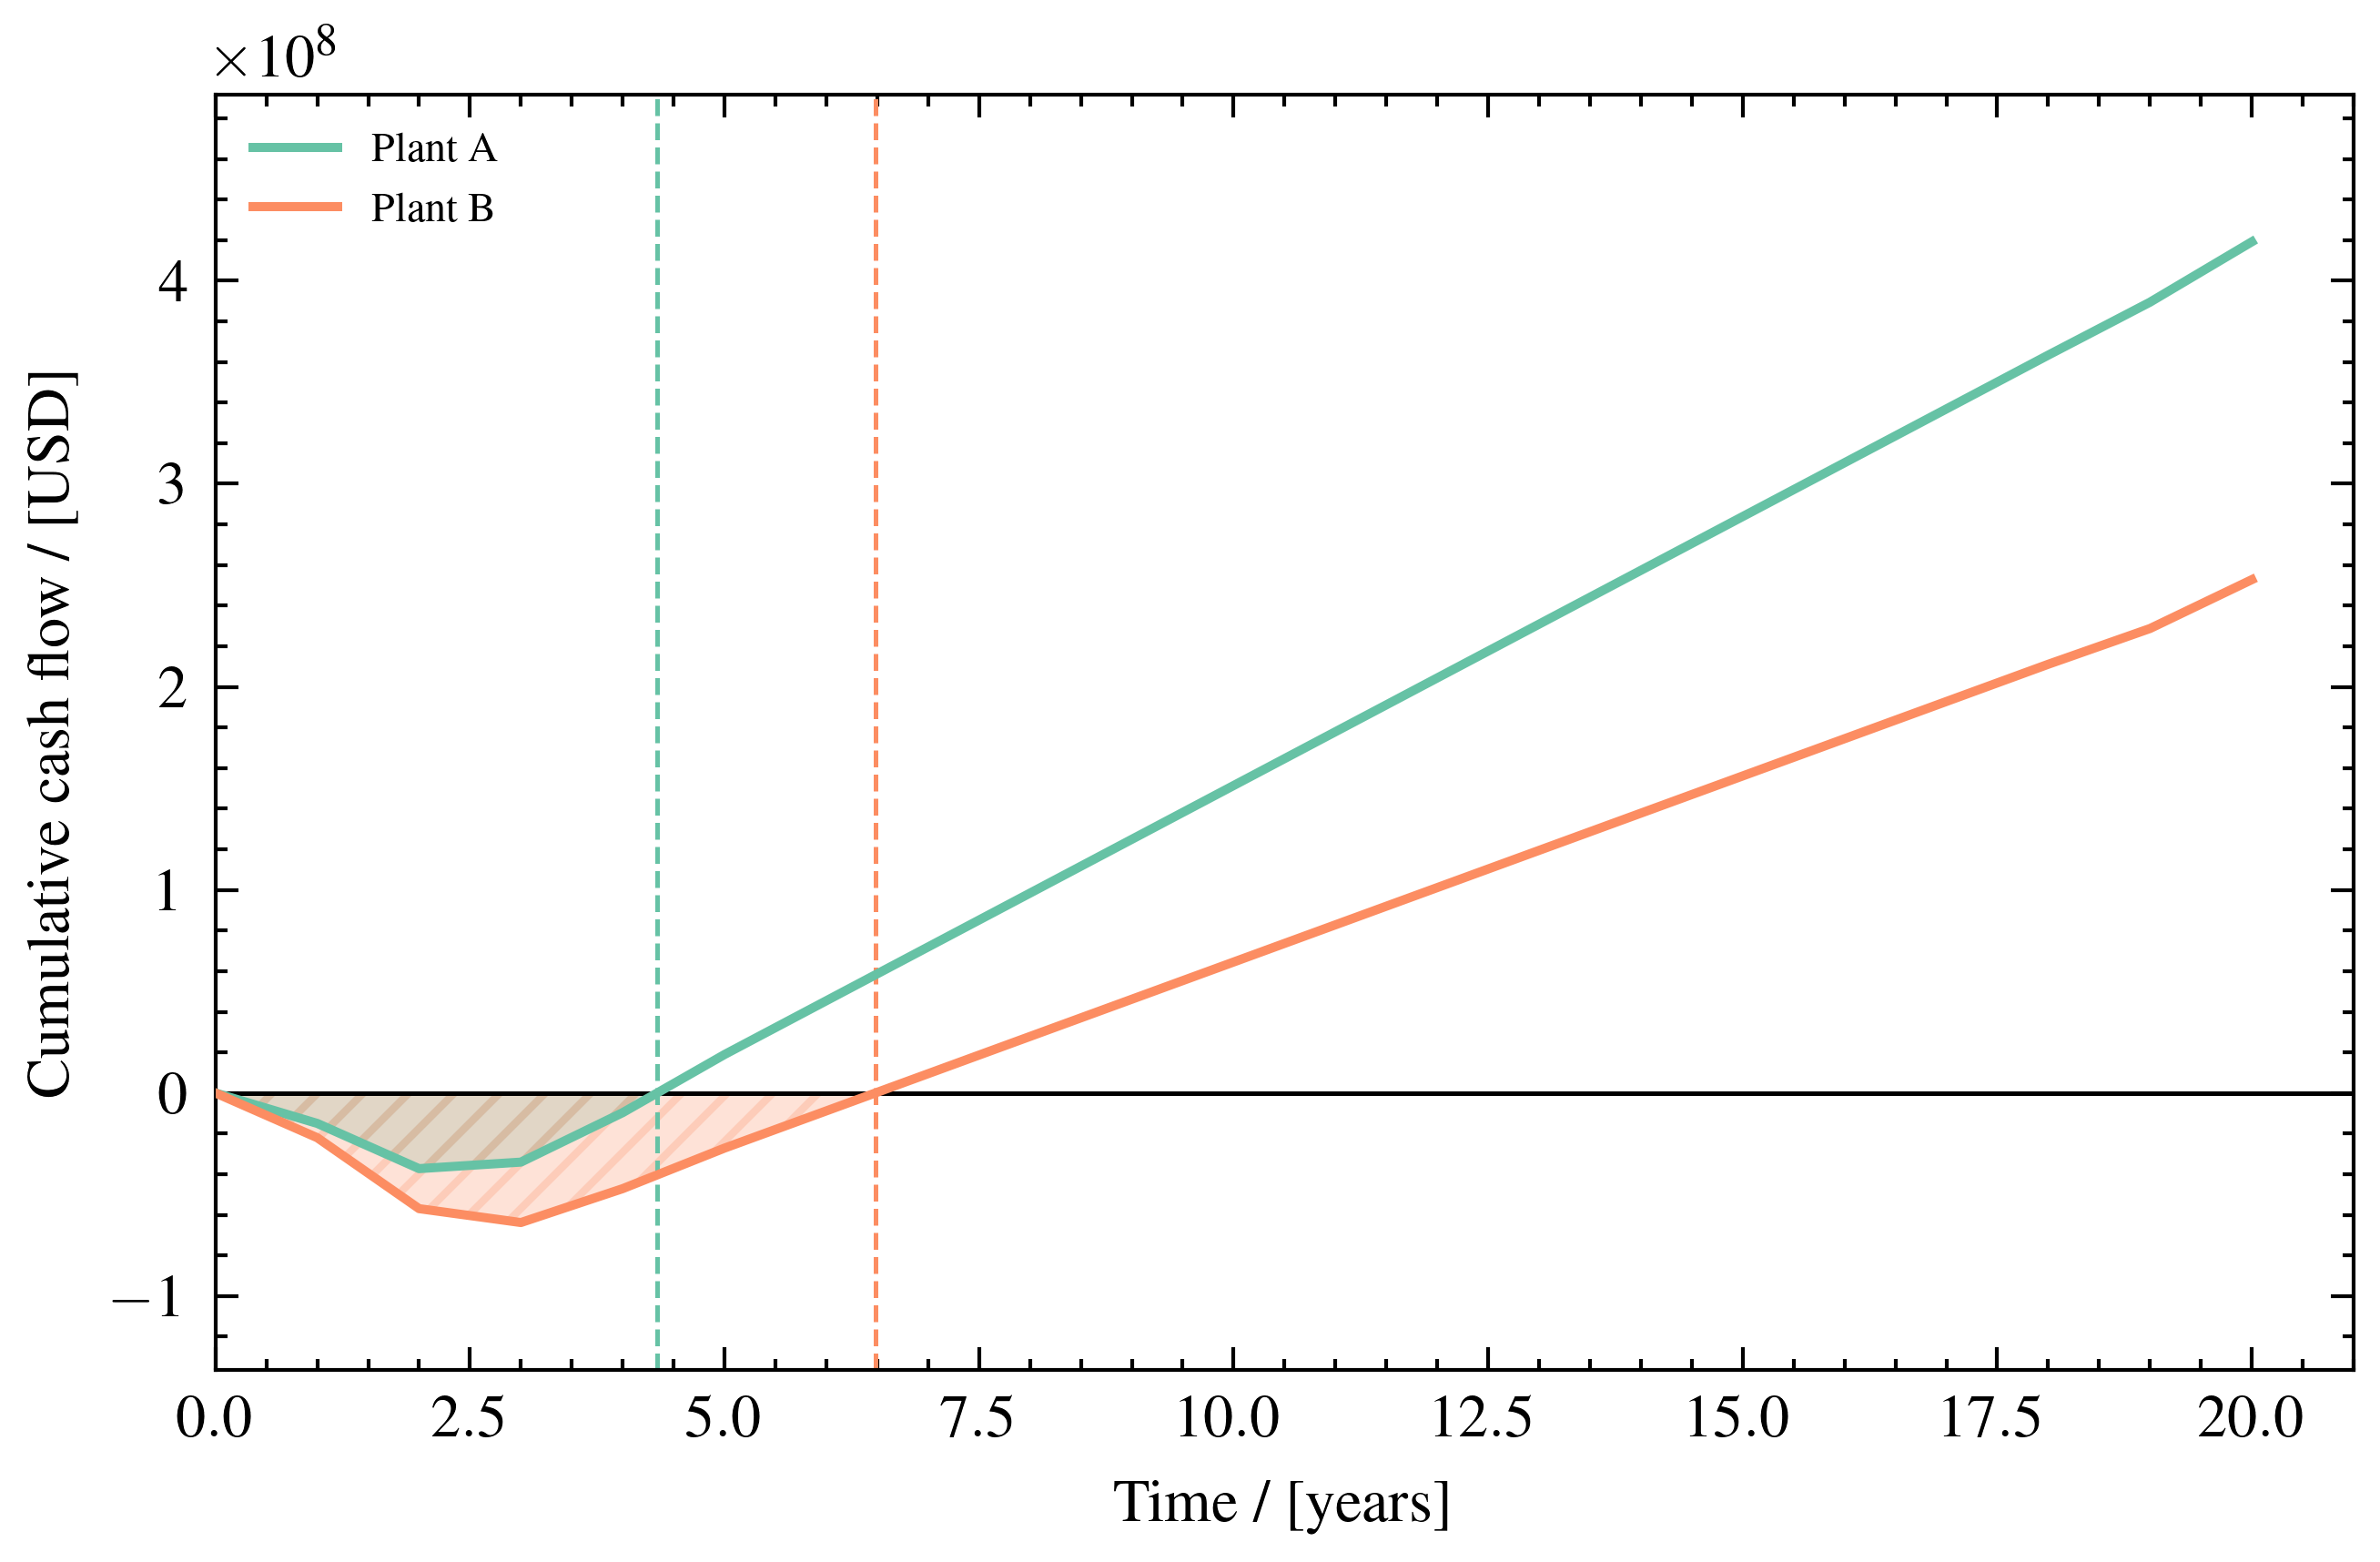

In [7]:
# A second plant with a bigger reactor (higher CAPEX) for comparison
config_b = dict(config_a)
config_b["plant_name"] = "Plant B"
config_b["equipment"] = [
    Equipment(
        name="Reactor R-101",
        param=90*2,
        process_type="Fluids",
        category="Reactors",
        type="Glass-lined agitated",
        material="316 stainless steel",
    ),
    hx,
    comp,
]
config_b["plant_products"] = {
    "methanol": {"production": 100_000, "price": 2.2},
}

plant_b = Plant(config_b)

data_multi = cash_flow_data([plant_a, plant_b])
fig, ax = plot_cash_flow(data_multi, figsize=(4.5, 3))